In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.community_detection import CommunityDetection
from src.ansatze import Ansatz
from src.simulator import QuimbSimulator
from src.optimizer import COBYLA, SMO, Adam
from src.lvqe import LayerVQE

from quantum_walk.community_detection_qw import detect_communities, modularity, top_k_degree_vertices, visualize_communities



Graph seed used: 14


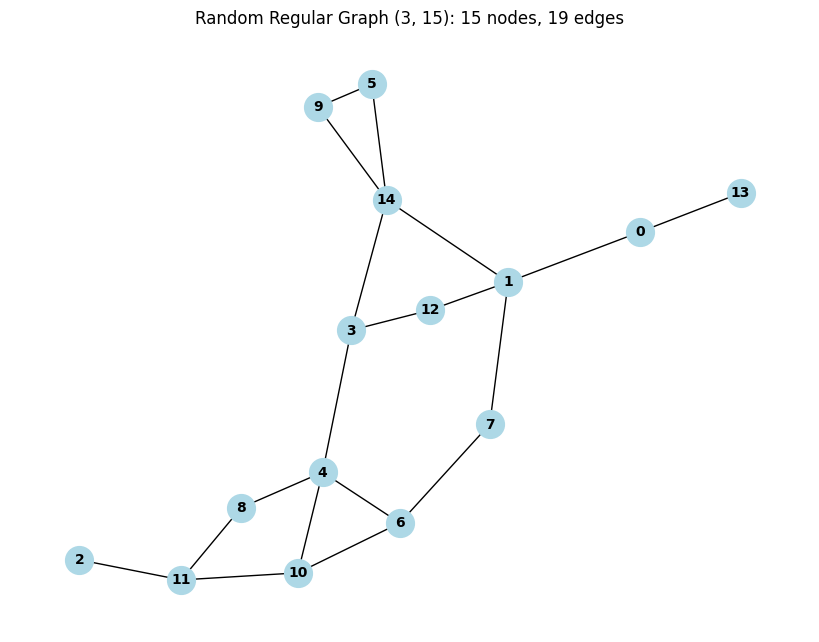

In [3]:
N = 15 
seed = 10
G = nx.gnp_random_graph(N, p=0.15, seed=seed)
while not nx.is_connected(G):
    seed += 1
    G = nx.gnp_random_graph(N, p=0.15, seed=seed)
print(f"Graph seed used: {seed}")

# plot
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=seed)
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=400, font_size=10, font_weight='bold')
plt.title(f"Random Regular Graph (3, {N}): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

In [4]:
k = 4

V_max = top_k_degree_vertices(G, k)
print(f"V_max (highest-degree nodes): {V_max}")

result_qw = detect_communities(
    G, V_max,
    q=None,         
    epsilon=1e-4,
    max_steps=int(1e6),
    min_steps=50,
    refine=False,
    verbose=False
)

qw_communities = result_qw['communities']
qw_modularity = modularity(G, qw_communities)


print(f"QW converged: {result_qw['converged']} in {result_qw['steps_run']} steps")
print(f"QW communities found: {len(qw_communities)}")
for rep, members in qw_communities.items():
    print(f"  community {rep}: {members}")
print(f"QW modularity: {qw_modularity:.4f}")

V_max (highest-degree nodes): [1, 14, 4, 10]
QW converged: True in 1209 steps
QW communities found: 3
  community 4: [10, 11, 12, 3, 4, 6, 7, 8]
  community 14: [0, 1, 13, 14, 5, 9]
  community 2: [2]
QW modularity: 0.2978


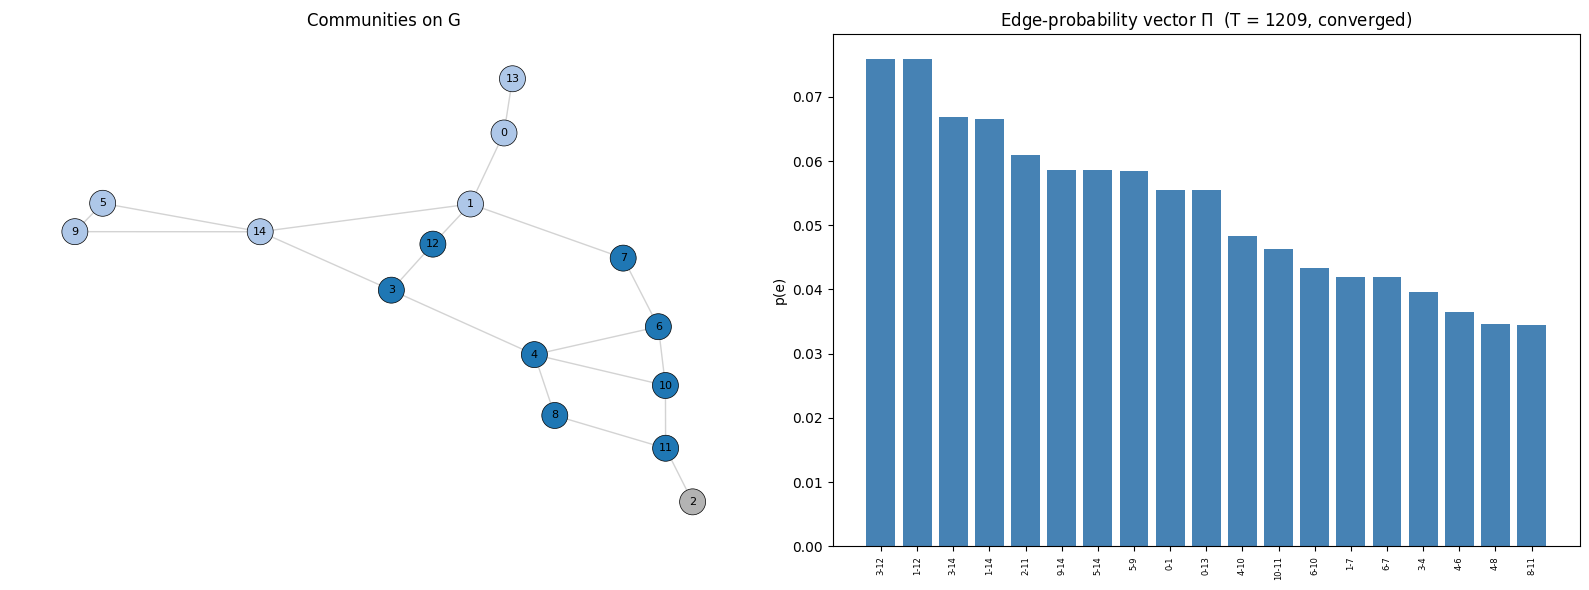

In [5]:
visualize_communities(G, result_qw)

Walk runtime:           0.016 s
Procedure (200 q vals): 0.038 s  (0.19 ms/call)


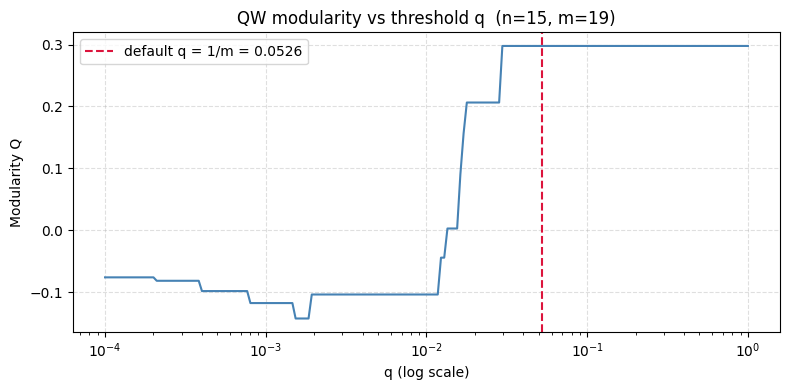

Best q: 0.029673  →  modularity: 0.2978
Default q (1/m): 0.052632  →  modularity: 0.2978


In [6]:
import time
from quantum_walk.community_detection_qw import create_walk_operator, run_walk, procedure, modularity

walk_operator = create_walk_operator(G)
V_max = top_k_degree_vertices(G, k)

t0 = time.perf_counter()
walk_run = run_walk(walk_operator, V_max, epsilon=1e-4, max_steps=2000, min_steps=50)
t_walk = time.perf_counter() - t0

Pi = walk_run['Pi']
edge_index = walk_run['edge_index']
m = G.number_of_edges()
q_default = 1.0 / m

q_values = np.logspace(np.log10(1e-4), np.log10(1.0), 200)
modularities = []

t0 = time.perf_counter()
for q in q_values:
    comms = procedure(G, Pi, edge_index, q, refine=False)
    modularities.append(modularity(G, comms))
t_procedure = time.perf_counter() - t0

print(f"Walk runtime:           {t_walk:.3f} s")
print(f"Procedure (200 q vals): {t_procedure:.3f} s  ({t_procedure/200*1000:.2f} ms/call)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q_values, modularities, color='steelblue', linewidth=1.5)
ax.axvline(q_default, color='crimson', linestyle='--', label=f'default q = 1/m = {q_default:.4f}')
ax.set_xscale('log')
ax.set_xlabel('q (log scale)')
ax.set_ylabel('Modularity Q')
ax.set_title(f'QW modularity vs threshold q  (n={G.number_of_nodes()}, m={m})')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

best_q = q_values[np.argmax(modularities)]
print(f"Best q: {best_q:.6f}  →  modularity: {max(modularities):.4f}")
print(f"Default q (1/m): {q_default:.6f}  →  modularity: {modularities[np.argmin(np.abs(q_values - q_default))]:.4f}")

Communities: 3
  4: [10, 11, 12, 3, 4, 6, 7, 8]
  14: [0, 1, 13, 14, 5, 9]
  2: [2]
Modularity: 0.2978


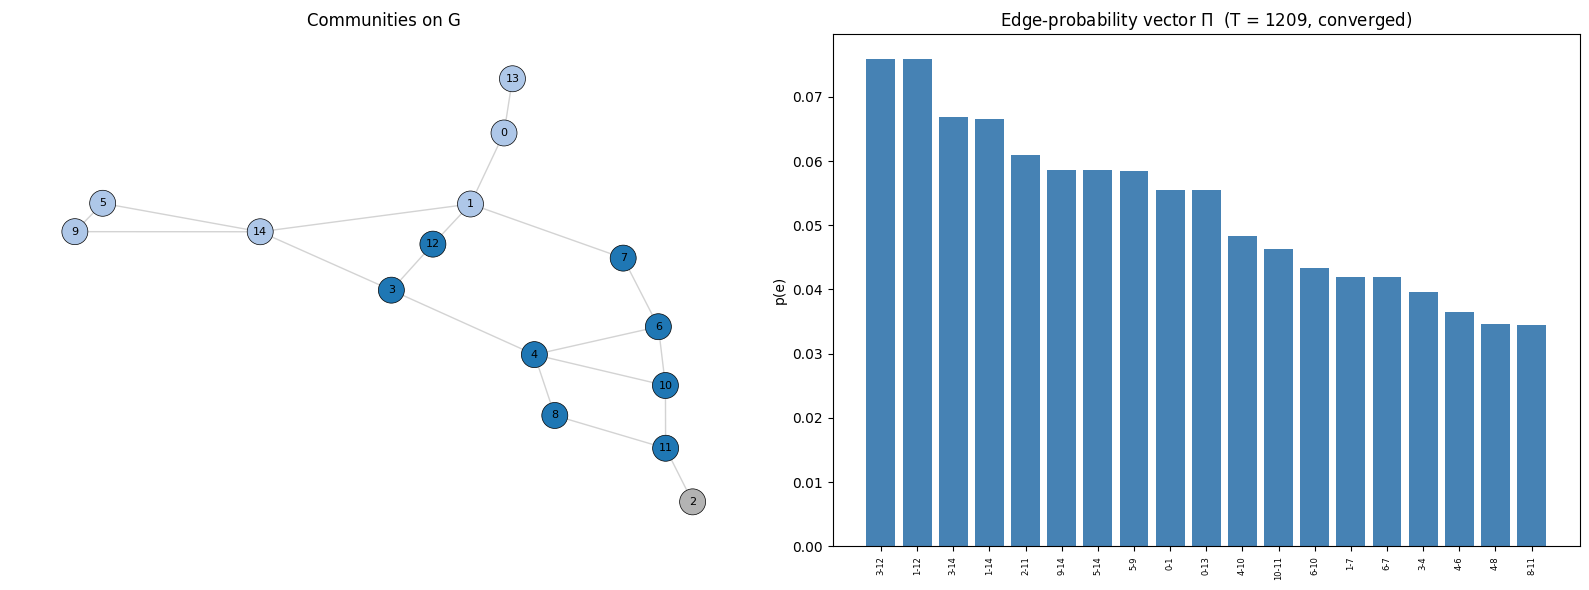

In [7]:
best_result = detect_communities(
    G, V_max,
    q=best_q,
    epsilon=1e-4,
    max_steps=2000,
    min_steps=50,
    refine=False,
    verbose=False
)
print(f"Communities: {len(best_result['communities'])}")
for rep, members in best_result['communities'].items():
    print(f"  {rep}: {members}")
print(f"Modularity: {modularity(G, best_result['communities']):.4f}")
visualize_communities(G, best_result)

In [8]:
# Epsilon sweep: convergence steps and modularity vs. epsilon
eps_values = np.array([1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5])

walk_operator = create_walk_operator(G)
V_max = top_k_degree_vertices(G, k)
q_default = 1.0 / G.number_of_edges()

eps_steps = []
eps_modularity = []
eps_converged = []

for eps in eps_values:
    walk_run = run_walk(walk_operator, V_max, epsilon=eps, max_steps=10000, min_steps=50)
    comms = procedure(G, walk_run["Pi"], walk_run["edge_index"], q_default, refine=False)
    Q = modularity(G, comms)

    eps_steps.append(walk_run["steps_run"])
    eps_modularity.append(Q)
    eps_converged.append(walk_run["converged"])

    print(f"eps={eps:.0e}  steps={walk_run['steps_run']:5d}  "
          f"converged={walk_run['converged']!s:5}  modularity={Q:.4f}")

eps_steps = np.array(eps_steps)
eps_modularity = np.array(eps_modularity)

eps=1e-01  steps=   50  converged=True   modularity=0.2978
eps=5e-02  steps=   50  converged=True   modularity=0.2978
eps=1e-02  steps=   50  converged=True   modularity=0.2978
eps=5e-03  steps=   50  converged=True   modularity=0.2978
eps=1e-03  steps=  163  converged=True   modularity=0.2978
eps=5e-04  steps=  268  converged=True   modularity=0.2978
eps=1e-04  steps= 1209  converged=True   modularity=0.2978
eps=5e-05  steps= 2684  converged=True   modularity=0.2978
eps=1e-05  steps= 9698  converged=True   modularity=0.2978


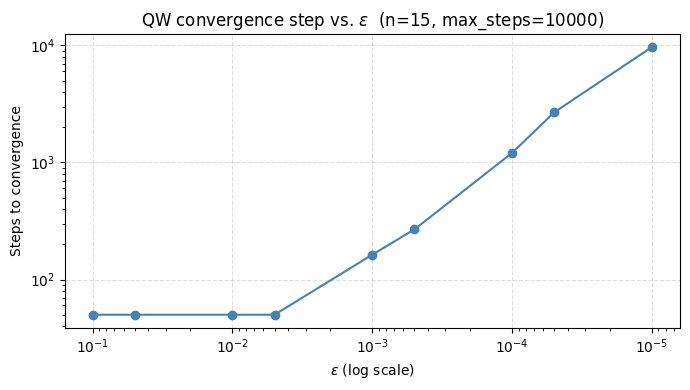

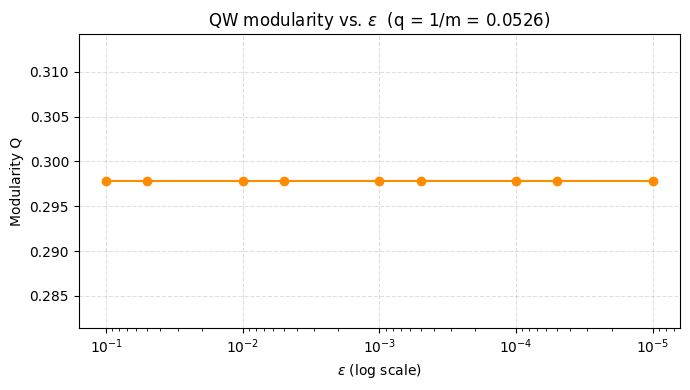

In [10]:
# Plot: convergence step vs. epsilon
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eps_values, eps_steps, marker="o", color="steelblue")
ax.set_yscale("log")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel(r"$\epsilon$ (log scale)")
ax.set_ylabel("Steps to convergence")
ax.set_title(f"QW convergence step vs. $\\epsilon$  (n={G.number_of_nodes()}, max_steps=10000)")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Plot: modularity vs. epsilon
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eps_values, eps_modularity, marker="o", color="darkorange")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_xlabel(r"$\epsilon$ (log scale)")
ax.set_ylabel("Modularity Q")
ax.set_title(f"QW modularity vs. $\\epsilon$  (q = 1/m = {q_default:.4f})")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()